# Classification is a problem of predicting whether something is one thing or another (can be multiple things as well)

## 1. Make classification data and get it ready

In [1]:
import sklearn

In [2]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples=n_samples, noise=0.03, random_state=42)
len(X), len(y)

(1000, 1000)

In [3]:
print(f"First 5 samples of X: {X[:5]}")
print(f"First 5 samples of y: {y[:5]}")
X.shape, y.shape

First 5 samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y: [1 1 1 1 0]


((1000, 2), (1000,))

In [4]:
import pandas as pd

circles = pd.DataFrame({"X0": X[:, 0], "X1": X[:, 1], "label": y})
circles.head(10)

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [5]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

Visualize is important

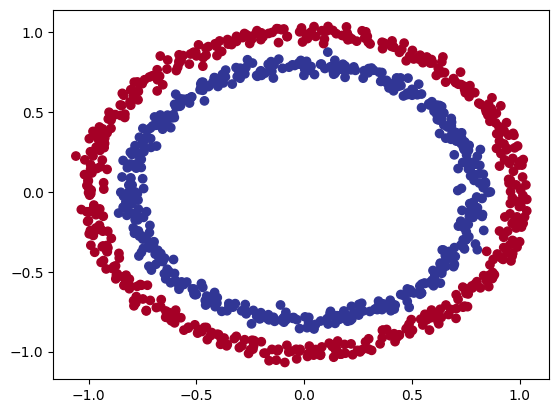

In [6]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

**Note**: This is toy dataset (small, sizeable to practice)
https://scikit-learn.org/stable/datasets/toy_dataset.html

### Check input & output shapes

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [9]:
# First example of feature & labels
X_Sample = X[0]
Y_Sample = y[0]

print(f"First sample of X: {X_Sample}")
print(f"First sample of y: {Y_Sample}")
print(f"Shape of X_Sample: {X_Sample.shape}")
print(f"Shape of Y_Sample: {Y_Sample.shape}")

First sample of X: [0.75424625 0.23148074]
First sample of y: 1
Shape of X_Sample: (2,)
Shape of Y_Sample: ()


### Turn data into tensor and create train and test splits

In [10]:
import torch

torch.__version__

'2.11.0+cu128'

In [11]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [12]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [13]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [14]:
# Split data into training and test sets 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split data into 80% train and 20% test
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a model

Build a mode to classify our blue and red dots.

we went to:
1. Setup device agonistic code
2. Construct a mode 
3. Define a loss function and optimizer
4. Create a training and testing loop

In [15]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [16]:
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### Create a model
1. Subclasses `nn.Module` 
2. Create 2 `nn.Linear()` to handle the shape of data (linear regression)
3. Defines a `forward()` method that outline the forward computation
4. Instatitate an instance of model class and send it to target `device`

In [17]:
# 1 Construct a model by subclassing nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        # 2. Create 2 nn.Linear layers
        super().__init__() # [X0, X1] -> [Y/N] <--- binary classification
        self.layer_1 = nn.Linear(in_features=2, out_features=8) # Hidden layer with 5 neurons
        self.layer_2 = nn.Linear(in_features=8, out_features=1) # Output layer with 1 neuron (binary classification)
    
    # 3. Define a forward method to specify how data should pass through the model
    def forward(self, x):
        # A
        # x = self.layer_1(x) # Pass data through hidden layer
        # x = torch.relu(x) # Apply ReLU activation function
        # x = self.layer_2(x) # Pass data through output layer
        # return x
        
        # same as A
        return self.layer_2(self.layer_1(x)) # Pass data through hidden layer, apply ReLU activation function, then pass data through output layer
    
# 4. Instantiate the model and send it to the target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=8, bias=True)
  (layer_2): Linear(in_features=8, out_features=1, bias=True)
)

In [18]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [19]:
# Replicate the model above using nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=8), # Hidden layer with 8 neurons
    nn.Linear(in_features=8, out_features=1) # Output layer with 1 neuron (binary classification)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): Linear(in_features=8, out_features=1, bias=True)
)

In [20]:
model_0.state_dict()
# 8 bias because 8 neurons in hidden layer, 1 bias because 1 neuron in output layer (linear layers y = ax + b )
# 8 weights because 8 neurons in hidden layer, 8 weights because 8 neurons in hidden layer and 1 neuron in output layer (linear layers y = ax + b ) 

OrderedDict([('0.weight',
              tensor([[ 0.2504,  0.6602],
                      [-0.6394, -0.7005],
                      [-0.4467, -0.3542],
                      [ 0.3693, -0.6691],
                      [-0.6510, -0.1384],
                      [-0.4621,  0.2233],
                      [ 0.6341, -0.5512],
                      [-0.2432,  0.3134]], device='cuda:0')),
             ('0.bias',
              tensor([-0.1151, -0.1765,  0.5503,  0.2912, -0.5256,  0.0293,  0.2352,  0.3952],
                     device='cuda:0')),
             ('1.weight',
              tensor([[-0.2816,  0.2658, -0.2506, -0.2713,  0.2286,  0.0489, -0.0539, -0.2162]],
                     device='cuda:0')),
             ('1.bias', tensor([0.0175], device='cuda:0'))])

In [21]:
# Make predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, shape of predictions: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, shape of test samples X_test: {X_test.shape}")
print(f"\nFirst 10 predictions: {torch.round(untrained_preds[:10])}")
print(f"\nFirst 10 labels: {y_test[:10]}")

Length of predictions: 200, shape of predictions: torch.Size([200, 1])
Length of test samples: 200, shape of test samples X_test: torch.Size([200, 2])

First 10 predictions: tensor([[-0.],
        [-1.],
        [-0.],
        [-0.],
        [-0.],
        [-1.],
        [-1.],
        [-1.],
        [-0.],
        [-1.]], device='cuda:0')

First 10 labels: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [22]:
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Setup loss function and optimizer

Which loss function or optimizer should be used?

> It depends on the problem.

- **Regression:** `L1Loss()` / `MSELoss()`
- **Classification:** `BCELoss()` / `CrossEntropyLoss()`

**Note:** A loss function measures *how wrong* your model predictions are.
> `L1Loss()`: Mean absoluted error  
> `MSELoss()`: Mean squared error  

Common optimizers include:

- `torch.optim.SGD`
- `torch.optim.Adam`

---

### Binary Classification Loss

For this project, we use:

```python
loss_fn = torch.nn.BCEWithLogitsLoss()
```

`BCEWithLogitsLoss()` combines:

```text
Sigmoid activation + Binary Cross Entropy loss
```

Flow:

```text
-----------      --------------      ---------------
| Logits  | ---> | Activation | ---> | Probability |
-----------      --------------      ---------------
```

Where:

- **Logits** = raw scores from the model
- **Activation** = converts logits into probabilities between 0 and 1
- **Probability** = final prediction confidence

In [23]:
# Setup the loss function
loss_fn = nn.BCEWithLogitsLoss() # Binary Cross Entropy with Logits Loss (combines a Sigmoid layer and the BCELoss in one single class)
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1) # Stochastic Gradient Descent optimizer

In [24]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.2504,  0.6602],
                      [-0.6394, -0.7005],
                      [-0.4467, -0.3542],
                      [ 0.3693, -0.6691],
                      [-0.6510, -0.1384],
                      [-0.4621,  0.2233],
                      [ 0.6341, -0.5512],
                      [-0.2432,  0.3134]], device='cuda:0')),
             ('0.bias',
              tensor([-0.1151, -0.1765,  0.5503,  0.2912, -0.5256,  0.0293,  0.2352,  0.3952],
                     device='cuda:0')),
             ('1.weight',
              tensor([[-0.2816,  0.2658, -0.2506, -0.2713,  0.2286,  0.0489, -0.0539, -0.2162]],
                     device='cuda:0')),
             ('1.bias', tensor([0.0175], device='cuda:0'))])

In [25]:
# Calculate accuracy (How good our model is at predicting labels of our data)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # Count how many predictions are correct
    acc = (correct / len(y_pred)) * 100 # Calculate accuracy
    return acc

## 3. Train model

Training loop:
1. Forward Pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step (gradient descend)

### 3.1 Going from raw logits -> prediction probabilities -> prediction tables

Model output are going to be raw **logits**

Can convert these **logits** into prediction probabilities by passing them to some kind of **activation function** 
(e.g `sigmoid` for binary classification and `softmax` for muliticlass classification)  

Then convert model's prediction probabilities to **prediction table** by either `rounding` them or taking the `argmax()`

In [26]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval() # Set the model to evaluation mode (turns off dropout and batch normalization layers if they exist)
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:8]
y_logits


tensor([[-0.3973],
        [-0.5909],
        [-0.1120],
        [-0.4772],
        [-0.4649],
        [-0.5804],
        [-0.8459],
        [-0.8444]], device='cuda:0')

In [27]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

$y_{test} \ne y_{logits}$  

$y_{test}: 1, 0 $  

$y_{logits}: \pm 0.xxxx$ 

In [28]:
# Use sigmoid to turn raw logits into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4020],
        [0.3564],
        [0.4720],
        [0.3829],
        [0.3858],
        [0.3588],
        [0.3003],
        [0.3006]], device='cuda:0')

For our prediciotn probability values, we need to perform a range-style rounding on them:
* `y_pred_probs` >= 0.5, y= 1 (class 1)
* `y_pred_probs` M 0.5, y = 0 (class 0)

> Usually use `0.5` as threshold

In [29]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# In full (logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:8]))

# Check for equality with torch.eq()
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimensions
y_preds.squeeze()


tensor([True, True, True, True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')

In [30]:
y_test[:8], y_pred_labels[:8]

(tensor([1., 0., 1., 0., 1., 1., 0., 0.]),
 tensor([[0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.]], device='cuda:0', grad_fn=<SliceBackward0>))

### 3.2 Building a training and testing loop
 

In [31]:
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# Build training loop
for epoch in range(epochs):
    ## Training
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(X_train).squeeze() # Get raw logits (model outputs)
    y_pred = torch.round(torch.sigmoid(y_logits)) # Turn logits -> pred probs -> pred labels

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train) # Calculate loss (note: BCEWithLogitsLoss expects raw logits, not pred probs)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad 
    optimizer.zero_grad()

    # 4. Loss backward (backpropagation)
    loss.backward()

    # 5. Optimizer step (gradient descent)
    optimizer.step()

    ## Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate loss/accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")






Epoch: 0 | Loss: 0.7258, Accuracy: 49.88% | Test Loss: 0.7158, Test Accuracy: 49.00%
Epoch: 10 | Loss: 0.7065, Accuracy: 42.25% | Test Loss: 0.6994, Test Accuracy: 47.50%
Epoch: 20 | Loss: 0.6994, Accuracy: 45.50% | Test Loss: 0.6940, Test Accuracy: 51.00%
Epoch: 30 | Loss: 0.6964, Accuracy: 46.50% | Test Loss: 0.6923, Test Accuracy: 52.00%
Epoch: 40 | Loss: 0.6949, Accuracy: 47.38% | Test Loss: 0.6919, Test Accuracy: 53.50%
Epoch: 50 | Loss: 0.6942, Accuracy: 48.00% | Test Loss: 0.6920, Test Accuracy: 53.50%
Epoch: 60 | Loss: 0.6937, Accuracy: 48.38% | Test Loss: 0.6923, Test Accuracy: 53.50%
Epoch: 70 | Loss: 0.6934, Accuracy: 48.00% | Test Loss: 0.6926, Test Accuracy: 51.50%
Epoch: 80 | Loss: 0.6933, Accuracy: 48.50% | Test Loss: 0.6929, Test Accuracy: 49.50%
Epoch: 90 | Loss: 0.6932, Accuracy: 49.75% | Test Loss: 0.6932, Test Accuracy: 46.50%


## 4. Make predictions and evaluate the model

From the metrics it looks like out model isn't learning anything...

So to inspect it let's make some predictions and make them visual!!

To do so, going to import a function called `plot_decision_boundary()`

In [32]:
import requests
from pathlib import Path

# Download helper functions from GitHub
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download.")
else:
    print("Downloading helper_functions.py...")
    response = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(response.content)
    print("Download complete.")

from helper_functions import plot_predictions, plot_decision_boundary



helper_functions.py already exists, skipping download.


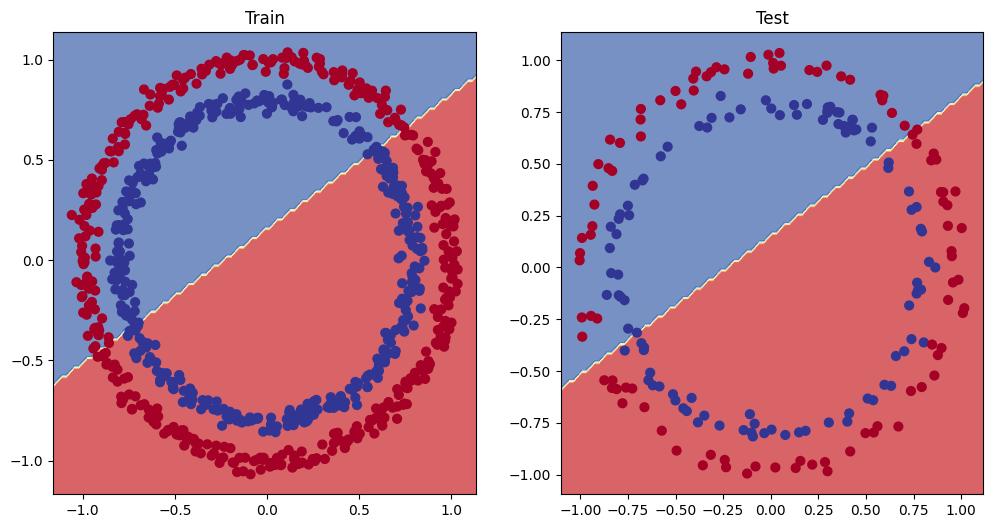

In [33]:
# Plot decision boundary of the model
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

## 5. Improving a model (from model perspective)

* Add more layers - give the model more chances to learn about patterns in the data
* Add more hidden units 
* Fit for longer 
* Changing the activation function
* Change the learning rate
* Change the loss function

These options are all from a model's perspective because they deal directly with the model,  
rather than the data.

And because these options are all values we (as machine learning engineers and data  
scientists) can change, they are referred as **hyper parameters**

In [34]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.2139,  0.6346],
                      [-0.6149, -0.6841],
                      [-0.4802, -0.3781],
                      [ 0.3343, -0.6938],
                      [-0.6349, -0.1281],
                      [-0.4578,  0.2262],
                      [ 0.6335, -0.5512],
                      [-0.2680,  0.2961]])),
             ('0.bias',
              tensor([-0.1670, -0.1373,  0.5046,  0.2426, -0.4973,  0.0364,  0.2319,  0.3592])),
             ('1.weight',
              tensor([[-0.2092,  0.0737, -0.2513, -0.2382,  0.0223,  0.0122,  0.0264, -0.1477]])),
             ('1.bias', tensor([0.2144]))])

### Try improve model by:
* Adding more hidden unit:  8-> 16
* Increase the number of layer: 2 -> 3
* Increase the number of epochs: 100 -> 1000

In [35]:
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]], device='cuda:0'),
 tensor([1., 0., 0., 0., 1.], device='cuda:0'))

In [36]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=16)
        self.layer_2 = nn.Linear(in_features=16, out_features=16)
        self.layer_3 = nn.Linear(in_features=16, out_features=1)
    
    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))
    
model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=16, bias=True)
  (layer_2): Linear(in_features=16, out_features=16, bias=True)
  (layer_3): Linear(in_features=16, out_features=1, bias=True)
)

In [37]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.3790,  0.6517],
                      [-0.3764, -0.4388],
                      [-0.2394,  0.3438],
                      [ 0.6440, -0.5822],
                      [-0.0179, -0.5689],
                      [-0.5420,  0.6925],
                      [ 0.6692,  0.2825],
                      [ 0.6032, -0.0412],
                      [-0.6068,  0.6070],
                      [ 0.6137, -0.4793],
                      [ 0.2232, -0.0090],
                      [-0.2795,  0.6217],
                      [ 0.6680, -0.5485],
                      [ 0.4332,  0.6778],
                      [-0.5288, -0.0112],
                      [ 0.4970,  0.4221]], device='cuda:0')),
             ('layer_1.bias',
              tensor([ 0.2254, -0.5969,  0.3277,  0.5853, -0.2982, -0.5195,  0.2676,  0.0595,
                      -0.0101,  0.3666, -0.4824,  0.3827, -0.1275,  0.1798, -0.0357, -0.6680],
                     device='cuda:0')),
             ('la

In [38]:
# Create a loss function and optimizer for model_1
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer for model_1
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [39]:
torch.cuda.manual_seed(42)

# Training & testing loop for model_1
epoch = 1000

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epoch):
    ### Training 
    model_1.train()

    # 1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # Turn logits -> pred probs -> pred labels

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train) # Calculate loss (note: BCEWithLogitsLoss expects raw logits, not pred probs)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward (backpropagation)
    loss.backward()

    # 5. Optimizer step (gradient descent)
    optimizer.step()

    ### Testing
    model_1.eval()

    with torch.inference_mode():

        # 1. Forward pass
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate loss/accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")
        






Epoch: 0 | Loss: 0.6985, Accuracy: 50.00% | Test Loss: 0.7020, Test Accuracy: 49.50%
Epoch: 100 | Loss: 0.6930, Accuracy: 50.62% | Test Loss: 0.6955, Test Accuracy: 46.50%
Epoch: 200 | Loss: 0.6930, Accuracy: 51.00% | Test Loss: 0.6949, Test Accuracy: 45.50%
Epoch: 300 | Loss: 0.6930, Accuracy: 51.25% | Test Loss: 0.6947, Test Accuracy: 46.00%
Epoch: 400 | Loss: 0.6930, Accuracy: 51.12% | Test Loss: 0.6947, Test Accuracy: 46.00%
Epoch: 500 | Loss: 0.6930, Accuracy: 51.12% | Test Loss: 0.6947, Test Accuracy: 46.00%
Epoch: 600 | Loss: 0.6930, Accuracy: 51.00% | Test Loss: 0.6947, Test Accuracy: 46.00%
Epoch: 700 | Loss: 0.6930, Accuracy: 51.00% | Test Loss: 0.6947, Test Accuracy: 46.00%
Epoch: 800 | Loss: 0.6930, Accuracy: 51.00% | Test Loss: 0.6947, Test Accuracy: 46.00%
Epoch: 900 | Loss: 0.6930, Accuracy: 51.00% | Test Loss: 0.6947, Test Accuracy: 46.00%


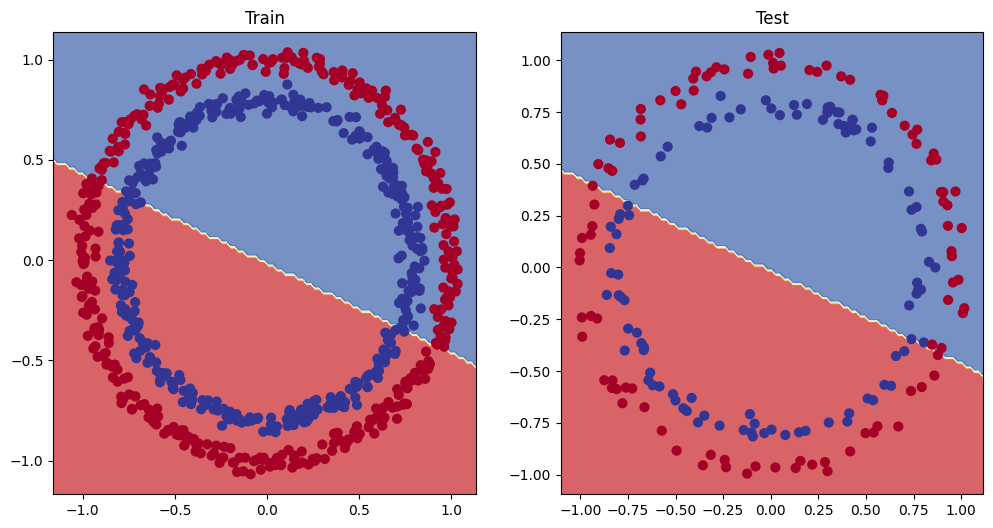

In [40]:
# Plot the decision boundary of model_1
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)


### 5.1 Preparing data to see if our model can fit a straight line

One way to troubleshoot to a larger problem is to test our a smaller problem

In [41]:
# Create some data (same as notebook 01)

weights = 0.7
bias = 0.3

start = 0 
end = 1
step = 0.01

# Create data 
X_regression = torch.arange(start, end, step).unsqueeze(dim=1) # Turn data into a column vector
y_regression = weights * X_regression + bias

# Check the data
print(len(X_regression), len(y_regression))
print(X_regression[:5], y_regression[:5])

100 100
tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400]]) tensor([[0.3000],
        [0.3070],
        [0.3140],
        [0.3210],
        [0.3280]])


In [42]:
# Create a train/test split
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the lengths of each 
print(len(X_train_regression), len(y_train_regression))
print(len(X_test_regression), len(y_test_regression))

80 80
20 20


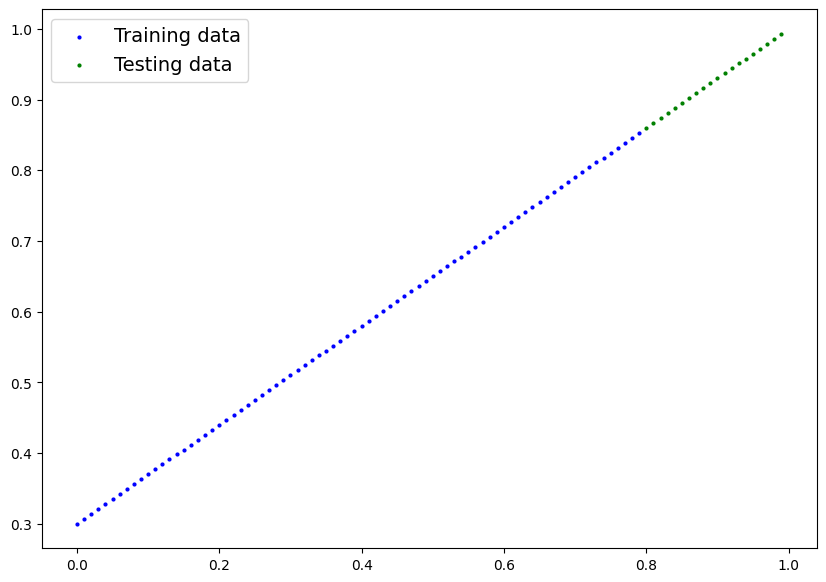

In [43]:
plot_predictions(X_train_regression, y_train_regression, X_test_regression, y_test_regression)

In [44]:
X_train_regression[:5], y_train_regression[:5]


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

### 5.2 Adjusting `model_` to fit a straight line

In [45]:
# Same architecture as model_1 but for regression
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=16), # Hidden layer with 16 neurons
    nn.Linear(in_features=16, out_features=16), # Hidden layer with 16 neurons
    nn.Linear(in_features=16, out_features=1) # Output layer with 1 neuron (regression)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): Linear(in_features=16, out_features=16, bias=True)
  (2): Linear(in_features=16, out_features=1, bias=True)
)

In [46]:
# Loss and optimizer for regression
loss_fn = nn.L1Loss() # Mean Absolute Error Loss
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [47]:
torch.cuda.manual_seed(42)

# Train the model

epochs = 1000

# Put the data on target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    ## Training 
    model_2.train()

    y_pred = model_2(X_train_regression)
    loss = loss_fn(y_pred, y_train_regression)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ## Testing
    model_2.eval()
    with torch.inference_mode():
        test_pred = model_2(X_test_regression)
        test_loss = loss_fn(test_pred, y_test_regression)

    # Printf out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")


Epoch: 0 | Loss: 0.32313 | Test loss: 0.48487
Epoch: 100 | Loss: 0.03330 | Test loss: 0.12185
Epoch: 200 | Loss: 0.03278 | Test loss: 0.11458
Epoch: 300 | Loss: 0.03799 | Test loss: 0.11078
Epoch: 400 | Loss: 0.03729 | Test loss: 0.10695
Epoch: 500 | Loss: 0.03388 | Test loss: 0.09970
Epoch: 600 | Loss: 0.03184 | Test loss: 0.09265
Epoch: 700 | Loss: 0.03133 | Test loss: 0.09162
Epoch: 800 | Loss: 0.02889 | Test loss: 0.08628
Epoch: 900 | Loss: 0.02756 | Test loss: 0.08240


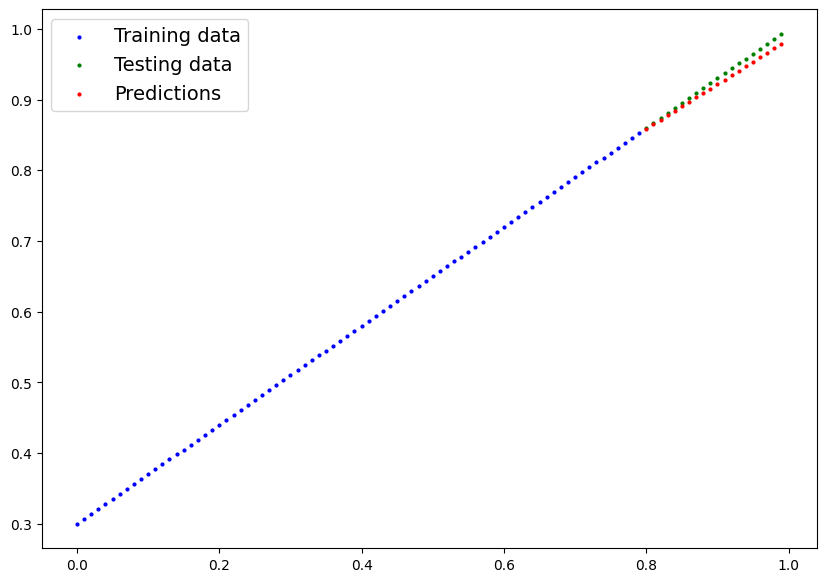

In [48]:
# Turn on eval mode
model_2.eval()

# Make predictions
with torch.inference_mode():
    test_pred = model_2(X_test_regression)



# Plot data & prdictions
plot_predictions(X_train_regression.cpu(), y_train_regression.cpu(), X_test_regression.cpu(), y_test_regression.cpu(), test_pred.cpu())

## 6. The non-linearity

"What pattern could you draw if you were given anb infinite amount of a straight and non-straight lines?"

**infinite** (really it is finite) or linear and non-linear functions?

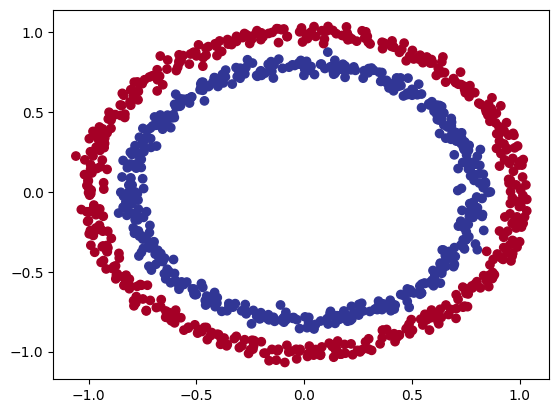

In [49]:
## 6.1 Recreating non-linear-data (red and blue circles)
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

X, y = make_circles(n_samples=n_samples, noise=0.03, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap= plt.cm.RdYlBu)
plt.show()

In [50]:
# Convert data to tensors and spllit into train/test
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: torch.Size([800, 2])
Shape of y_train: torch.Size([800])
Shape of X_test: torch.Size([200, 2])
Shape of y_test: torch.Size([200])


In [51]:
X_train[:5], y_train[:5]


(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.1 Building a model with non-linearity

* Linear = straight line
* Non-linear = non-straight lines

AI are a large combination of linear and non-linear 

In [52]:
# Build a model with non-linear activation function
from torch import nn

class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=16)
        self.layer_2 = nn.Linear(in_features=16, out_features=16)
        self.layer_3 = nn.Linear(in_features=16, out_features=1)
        self.relu = nn.ReLU() # Non-linear activation function

    def forward(self, x):
        # Where should we put our non-linear activation function?
        # Relu every layer (erase nagetive values as 0)
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
    
model_3 = CircleModelV2().to(device)
model_3


CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=16, bias=True)
  (layer_2): Linear(in_features=16, out_features=16, bias=True)
  (layer_3): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)

In [53]:
# Set up loss & optimizer

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)


### 6.2 Training model with non-linearity


In [54]:
# Random seed
torch.cuda.manual_seed(42)

# Data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 1000

# Training 
for epoch in range(epochs):
    ### Training 
    model_3.train()

    # 1. Forward
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> pred probs -> pred labels

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss expects raw logits, not pred probs
    acc = accuracy_fn(y_train, y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step
    optimizer.step()

    ### Testing
    model_3.eval()
    with torch.inference_mode():
        # 1. Forward 
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate loss/accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f} | Acc: {acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Epoch: 0 | Loss: 0.6999 | Acc: 50.0000 | Test Loss: 0.6988 | Test Acc: 50.0000
Epoch: 100 | Loss: 0.6853 | Acc: 60.6250 | Test Loss: 0.6881 | Test Acc: 53.0000
Epoch: 200 | Loss: 0.6794 | Acc: 67.2500 | Test Loss: 0.6844 | Test Acc: 62.5000
Epoch: 300 | Loss: 0.6706 | Acc: 69.1250 | Test Loss: 0.6775 | Test Acc: 62.5000
Epoch: 400 | Loss: 0.6562 | Acc: 74.0000 | Test Loss: 0.6647 | Test Acc: 67.5000
Epoch: 500 | Loss: 0.6306 | Acc: 88.7500 | Test Loss: 0.6410 | Test Acc: 83.0000
Epoch: 600 | Loss: 0.5808 | Acc: 98.6250 | Test Loss: 0.5939 | Test Acc: 95.0000
Epoch: 700 | Loss: 0.4875 | Acc: 99.8750 | Test Loss: 0.5059 | Test Acc: 99.5000
Epoch: 800 | Loss: 0.3461 | Acc: 100.0000 | Test Loss: 0.3735 | Test Acc: 100.0000
Epoch: 900 | Loss: 0.2100 | Acc: 100.0000 | Test Loss: 0.2460 | Test Acc: 100.0000


In [55]:
model_3.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 1.0621, -1.0415],
                      [-0.1616,  0.0082],
                      [-0.5501, -0.7771],
                      [ 0.2229,  0.5751],
                      [-0.7669, -0.9400],
                      [-0.6762, -0.2702],
                      [-0.9123, -1.1856],
                      [ 0.1287,  1.7600],
                      [-0.3255, -0.8235],
                      [ 0.1628,  0.7015],
                      [ 1.6994,  0.0691],
                      [-1.3214,  0.7528],
                      [-1.1227, -0.5165],
                      [ 0.1939,  0.4831],
                      [-0.5473, -0.1251],
                      [-0.8847,  1.1819]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3013, -0.5172,  1.0782,  0.8830, -0.1800, -0.7212,  0.1397, -0.1599,
                      -0.3731,  0.8718,  0.0257, -0.4026, -0.1796, -0.6761,  1.0324, -0.2741],
                     device='cuda:0')),
             ('la

### 6.3 Evaluating a model trained with non-linear activation functions

In [58]:
# Make predictions

model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test).squeeze()))

y_preds[:10], y_test[:10]


(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

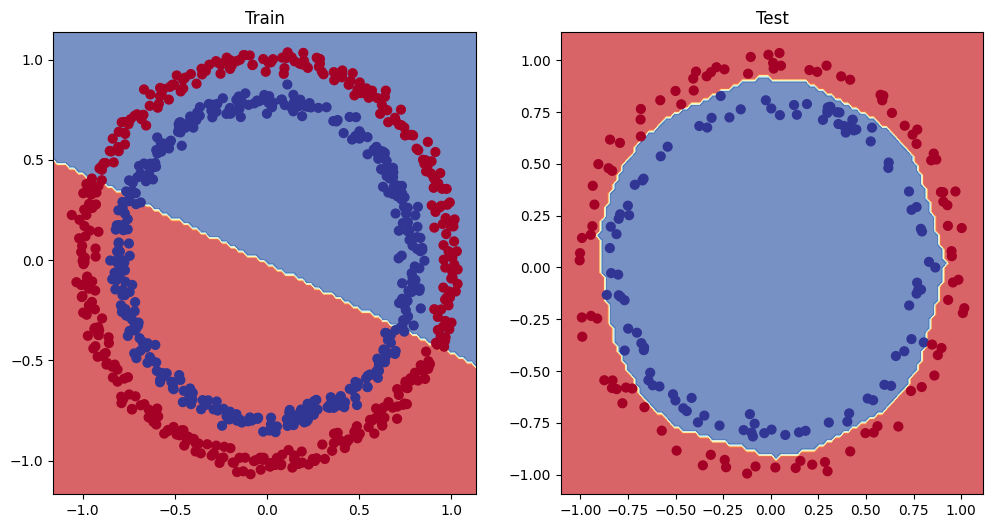

In [ ]:
# Plot decision boundaries
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # model_1 = no non-linear activation

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = with non-linear activation

## 7. Replicating non-linear activation functions

NN, rather than us telling the model what to learn, we give it the tools to discover patterns in data and  
it tries to figure out the pattern on its own.
**Tools** : Linear & non-linear functions.


In [65]:
# Create a tensor
A = torch.arange(-10, 10, 1.0, dtype=torch.float32) 
A.dtype

torch.float32

### 7.1 Linear

In [67]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

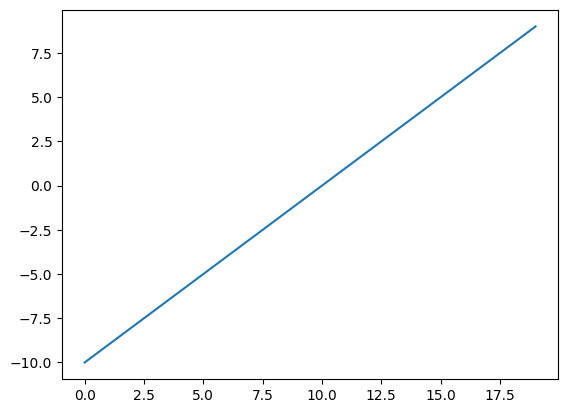

In [68]:
# Visualize the tensor
plt.plot(A)

### 7.2 Relu

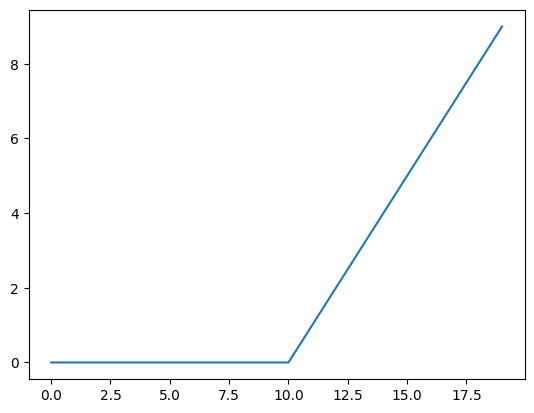

In [70]:
plt.plot(torch.relu(A))

In [71]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.max(torch.zeros_like(x), x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

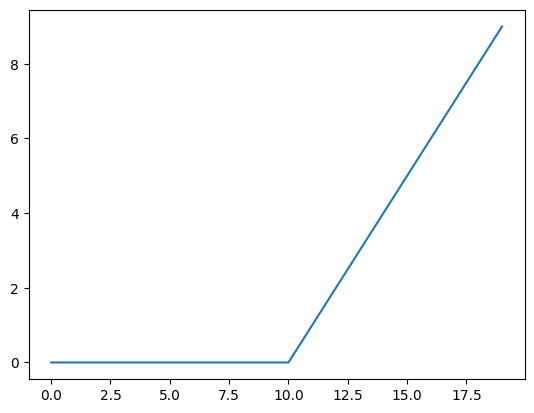

In [72]:
# Plot ReLU activation function
plt.plot(relu(A))

### 7.3 Sigmoid

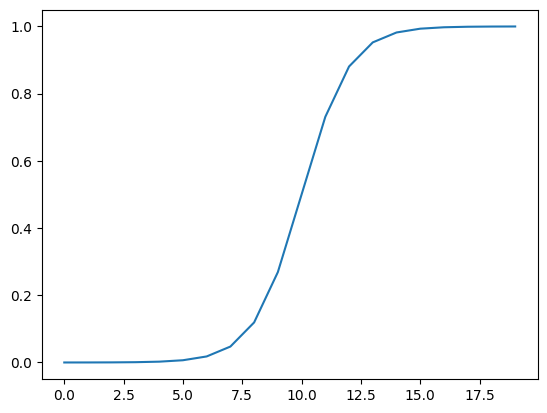

In [73]:
# Sigmoid
def sigmoid(x: torch.Tensor) -> torch.Tensor:
    return 1 / (1 + torch.exp(-x))

plt.plot(sigmoid(A))

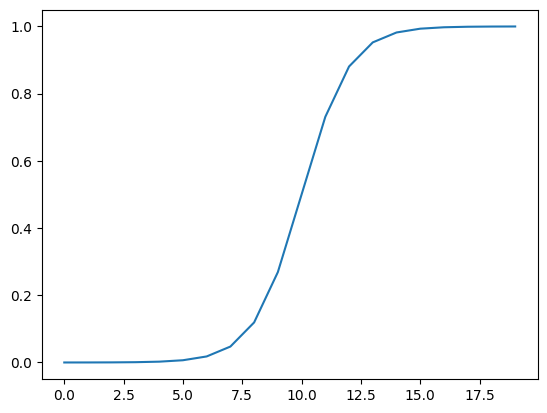

In [74]:
plt.plot(torch.sigmoid(A))

## 8. Putting it all tgt with a multi-calss classification problem

* Binary classification: Cat vs Dog

* Multi-class classification: Cat vs Dog vs Horse vs ...

### 8.1 Create a toy multi-class dataset

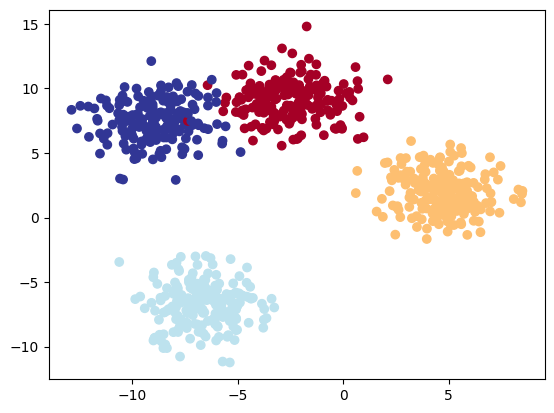

In [82]:
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000, 
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES, 
                            cluster_std= 1.5, # give the clusters a little shake up
                            random_state=RANDOM_SEED)
# 2. numpy -> tensor
X_blob = torch.from_numpy(X_blob).float()
y_blob = torch.from_numpy(y_blob).float()

# 3. Split into train and test
X_blob_train, X_blob_test = train_test_split(X_blob, test_size=0.2, random_state=RANDOM_SEED)
y_blob_train, y_blob_test = train_test_split(y_blob, test_size=0.2, random_state=RANDOM_SEED)

# 4. Plot data 
plt.Figure(figsize=(12, 7))
plt.scatter(X_blob_train[:, 0], X_blob_train[:, 1], c=y_blob_train, cmap=plt.cm.RdYlBu)
